1. Input Data

In [3]:
import numpy as np
import torch

data = np.load("frozen_soil_sensor_dataset_test.npz")

all_T        = data["all_T"]         # (n_case, Nt, Nz)   
all_T_sensor = data["all_T_sensor"]  # (n_case, Nt, n_s)  
params_arr   = data["params_arr"]    # (n_case, n_param)  
curve_ids    = data["curve_ids"]     # (n_case,)
t            = data["t"]             # (Nt,)
z            = data["z"]             # (Nz,)
sensor_z     = data["sensor_z"]      # (n_s,)
sensor_idx   = data["sensor_idx"]    # (n_s,)

print("all_T       :", all_T.shape)
print("all_T_sensor:", all_T_sensor.shape)
print("params_arr  :", params_arr.shape)
print("curve_ids   :", curve_ids.shape)
print("t           :", t.shape)
print("z           :", z.shape)
print("sensor_z    :", sensor_z)
print("sensor_idx  :", sensor_idx)

all_T       : (220, 61, 49)
all_T_sensor: (220, 61, 11)
params_arr  : (220, 6)
curve_ids   : (220,)
t           : (61,)
z           : (49,)
sensor_z    : [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]
sensor_idx  : [ 4  8 12 16 20 24 28 32 36 40 44]


2. Inverse DeepONet

In [4]:
X_sensor_np = all_T_sensor
X_sensor = torch.from_numpy(X_sensor_np).permute(0, 2, 1).float()
params   = torch.from_numpy(params_arr).float()

print("X_sensor for CNN:", X_sensor.shape)  
print("params          :", params.shape)


X_sensor for CNN: torch.Size([220, 11, 61])
params          : torch.Size([220, 6])


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BranchCNN(nn.Module):
    def __init__(self, n_sensors: int, latent_dim: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_sensors, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)  
        self.ln   = nn.LayerNorm(32)
        self.fc   = nn.Linear(32, latent_dim)

    def forward(self, x):
        # x: (B, n_sensors, Nt)
        h = self.conv(x)              # (B, 32, Nt)
        h = self.pool(h).squeeze(-1)  # (B, 32)
        h = self.ln(h)
        b = self.fc(h)                # (B, latent_dim = p)
        return b


class TrunkNet(nn.Module):
    def __init__(self, latent_dim: int = 64, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim)
        )

    def forward(self, T_query):          
        if T_query.dim() == 1:
            x = T_query.unsqueeze(-1)    # (n_T, 1)
        else:
            x = T_query.unsqueeze(-1)
        t = self.net(x)                  # (..., latent_dim)
        return t


class InverseDeepONetMonotone(nn.Module):
    def __init__(self,
                 n_sensors: int,
                 latent_dim: int = 64,
                 theta_sat: float = 0.5):
        super().__init__()
        self.branch     = BranchCNN(n_sensors, latent_dim)
        self.trunk      = TrunkNet(latent_dim)
        self.theta_sat  = theta_sat
        self.latent_dim = latent_dim

        self.fc_res = nn.Linear(latent_dim, 1)
        self.fc_scale = nn.Linear(latent_dim, 1)

    def forward(self, X_sensor, T_query):
        device = X_sensor.device
        T_query = T_query.to(device)

        B   = X_sensor.size(0)
        n_T = T_query.numel()

        mask_neg = (T_query < 0)          # (n_T,)
        mask_pos = ~mask_neg              # (n_T,)

        idx_neg = torch.nonzero(mask_neg, as_tuple=False).squeeze(-1)  # (n_T_neg,)
        idx_pos = torch.nonzero(mask_pos, as_tuple=False).squeeze(-1)  # (n_T_pos,)

        T_neg = T_query[idx_neg]          # (n_T_neg,)

        # b: (B, latent_dim)
        b = self.branch(X_sensor)         # (B, latent_dim)

        theta_res_frac = torch.sigmoid(self.fc_res(b))   # (B, 1), 0~1
        theta_res = theta_res_frac * self.theta_sat      # (B, 1)

        t_neg = self.trunk(T_neg)         # (n_T_neg, latent_dim)

        # raw: (B, n_T_neg)
        theta_raw_neg = torch.matmul(b, t_neg.T)   # (B, n_T_neg)

        scale = 0.2 + 5.0 * torch.sigmoid(self.fc_scale(b))   # (B,1) > 0
        delta = F.softplus(theta_raw_neg) * scale              # (B,n_T_neg)

        theta_cum = torch.cumsum(delta, dim=1)     # (B, n_T_neg)

        eps = 1e-6
        s_neg = theta_cum / (theta_cum[:, -1:].clone() + eps)   # (B, n_T_neg), 0~1
        theta_neg = theta_res + (self.theta_sat - theta_res) * s_neg  # (B, n_T_neg)
        theta = torch.zeros(B, n_T, device=device)

        if idx_neg.numel() > 0:
            theta[:, idx_neg] = theta_neg

        if idx_pos.numel() > 0:
            theta[:, idx_pos] = self.theta_sat

        return theta

3. Connect PDE solver

3.1. K and C_eff functions

In [6]:
import torch.nn as nn
import torch.nn.functional as F

n_porosity    = 0.5         
theta_s_fixed = 1.0 - n_porosity   

K_s = 8.80*86400       # W/m/K   
K_w = 0.56*86400       # W/m/K   
K_i = 2.26*86400       # W/m/K   

C_s = 2.13*1e6         # J/m3/K  
C_w = 4.19e6           # J/m3/K  
C_i = 2.13e6           # J/m3/K  

L     = 3.34e5         # J/kg    
rho_w = 1000.0         # kg/m3    


In [7]:

def interp_1d(T_nodes: torch.Tensor,
              T_query: torch.Tensor,
              y_query: torch.Tensor) -> torch.Tensor:

    T_min, T_max = T_query[0], T_query[-1]
    T_clamp = torch.clamp(T_nodes, T_min, T_max)

    n_T = T_query.shape[0]
    pos = (T_clamp - T_min) / (T_max - T_min) * (n_T - 1)

    idx0 = torch.floor(pos).long()
    idx1 = torch.clamp(idx0 + 1, max=n_T - 1)
    w    = (pos - idx0.float()).clamp(0.0, 1.0)

    y0 = y_query[idx0]
    y1 = y_query[idx1]
    y  = (1.0 - w) * y0 + w * y1
    return y


def sfcc_and_deriv_finite_diff_batch(
    deeponet: nn.Module,
    X_sensor_batch: torch.Tensor,  # (B, n_sensors, Nt)
    T_query: torch.Tensor,         # (n_T,)
    eps_T: float = 0.2,
    dtheta_max: float = 5.0
):
    
    device = T_query.device
    X_sensor_batch = X_sensor_batch.to(device)
    T_query = T_query.to(device)

    eps = float(eps_T)
    T_min, T_max = T_query[0], T_query[-1]
    T_plus  = torch.clamp(T_query + eps,  T_min, T_max)
    T_minus = torch.clamp(T_query - eps,  T_min, T_max)

    theta_center = deeponet(X_sensor_batch, T_query)   # (B, n_T)
    theta_plus   = deeponet(X_sensor_batch, T_plus)    # (B, n_T)
    theta_minus  = deeponet(X_sensor_batch, T_minus)   # (B, n_T)

    dtheta = (theta_plus - theta_minus) / (2.0 * eps)  # (B, n_T)
    dtheta = torch.clamp(dtheta, 0.0, dtheta_max)

    return theta_center, dtheta



In [8]:

def compute_K_from_theta(theta_w: torch.Tensor) -> torch.Tensor:
    
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    Ks_part = K_s ** theta_s
    Kw_part = K_w ** theta_w
    Ki_part = K_i ** theta_i

    return Ks_part * Kw_part * Ki_part


def compute_Ceff_from_theta_fdiff(
    theta_w: torch.Tensor,      # (Nz,)
    T_nodes: torch.Tensor,      # (Nz,)
    T_query: torch.Tensor,      # (n_T,)
    dtheta_query: torch.Tensor  # (n_T,)
) -> torch.Tensor:
    
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    C_T = theta_s * C_s + theta_w * C_w + theta_i * C_i   # (Nz,)

    dtheta_nodes = interp_1d(T_nodes, T_query, dtheta_query)  # (Nz,)

    C_eff = C_T + L * rho_w * dtheta_nodes
    return C_eff

3.2 PDE solver

In [9]:
def solve_one_case_with_sfcc_fdiff(
    theta_query: torch.Tensor,   # (n_T,)
    dtheta_query: torch.Tensor,  # (n_T,)
    T_query: torch.Tensor,       # (n_T,)
    z: torch.Tensor,             # (Nz,)
    t: torch.Tensor,             # (Nt,)
    T_initial: float,
    T_top_func
) -> torch.Tensor:
    
    device = theta_query.device
    z = z.to(device)
    t = t.to(device)

    dz  = z[1] - z[0]
    dt  = t[1] - t[0]
    Nz  = z.numel()
    Nt  = t.numel()
    dz2 = dz * dz

    T0 = torch.full((Nz,), float(T_initial),
                    dtype=torch.float32, device=device)
    T_list = [T0]  

    for n in range(Nt - 1):
        Tn = T_list[-1]   

        time_n1     = float(t[n+1].item())
        T_top_n1    = float(T_top_func(time_n1))

        theta_w = interp_1d(Tn, T_query, theta_query)   # (Nz,)
        K_T     = compute_K_from_theta(theta_w)         # (Nz,)
        C_eff   = compute_Ceff_from_theta_fdiff(
            theta_w, Tn, T_query, dtheta_query
        )                                               # (Nz,)

        K_half = 0.5 * (K_T[1:] + K_T[:-1])            # (Nz-1,)

        M = Nz - 2  

        a = torch.zeros(M-1, device=device)
        b = torch.zeros(M,   device=device)
        c = torch.zeros(M-1, device=device)
        d_vec = torch.zeros(M, device=device)

        for j in range(1, Nz-1):
            m = j - 1

            K_left  = K_half[j-1]     # K_{j-1/2}
            K_right = K_half[j]       # K_{j+1/2}
            Ci      = C_eff[j]

            a_m = -K_left  / dz2
            c_m = -K_right / dz2
            b_m = Ci / dt + (K_left + K_right) / dz2
            d_m = Ci / dt * Tn[j]

            if j == 1:
                b_m = b_m + a_m

            if j == Nz-2:
                d_m -= c_m * T_top_n1

            b[m]     = b_m
            d_vec[m] = d_m
            if m > 0:
                a[m-1] = a_m
            if m < M-1:
                c[m] = c_m

        A = torch.diag(b) + torch.diag(a, diagonal=-1) + torch.diag(c, diagonal=1)
        T_internal = torch.linalg.solve(A, d_vec)   # (M,)

        T_next = torch.empty_like(Tn)
        T_next[1:-1] = T_internal
        T_next[0]    = T_next[1]   # zero-flux
        T_next[-1]   = T_top_n1

        T_list.append(T_next)

    T_field = torch.stack(T_list, dim=0)   # (Nt, Nz)
    return T_field


3.3 Connect DeepONet and PDE

In [ ]:
class FrozenSoilDM(nn.Module):

    def __init__(self,
                 deeponet: nn.Module,
                 z_grid,
                 t_grid,
                 sensor_idx,
                 T_top_func,
                 T_initial: float,
                 theta_sat: float = 0.5,
                 T_min: float = -15.0,
                 T_max: float = 0.0,
                 n_T_query: int = 100):
        super().__init__()

        self.deeponet       = deeponet
        self.T_initial      = T_initial
        self.T_top_func     = T_top_func
        self.theta_sat      = theta_sat

        z_grid = np.asarray(z_grid, dtype=np.float32)
        t_grid = np.asarray(t_grid, dtype=np.float32)
        self.register_buffer("z", torch.from_numpy(z_grid))
        self.register_buffer("t", torch.from_numpy(t_grid))
        self.register_buffer(
            "sensor_idx",
            torch.as_tensor(sensor_idx, dtype=torch.long)
        )

        T_query_np = np.linspace(T_min, T_max, n_T_query).astype("float32")
        self.register_buffer("T_query", torch.from_numpy(T_query_np))

    def forward(self, X_sensor: torch.Tensor):
    
        device = X_sensor.device
        B, n_sensors, Nt_obs = X_sensor.shape

        z       = self.z.to(device)
        t       = self.t.to(device)
        T_query = self.T_query.to(device)
        idx_s   = self.sensor_idx.to(device)

        Nz = z.numel()
        Nt = t.numel()
        assert Nt_obs == Nt, "The number of observed time steps must be consistent with N_t in t_grid"

        theta_batch, dtheta_batch = sfcc_and_deriv_finite_diff_batch(
            self.deeponet,
            X_sensor,    # (B, n_sensors, Nt)
            T_query,     # (n_T,)
            eps_T=0.2,
            dtheta_max=5.0
        )  # (B, n_T), (B, n_T)

        T_fields = []
        for b in range(B):
            T_field = solve_one_case_with_sfcc_fdiff(
               theta_query=theta_batch[b],
               dtheta_query=dtheta_batch[b],
               T_query=T_query,
               z=z, t=t,
               T_initial=self.T_initial,
               T_top_func=self.T_top_func
            )
            T_fields.append(T_field)

        T_all = torch.stack(T_fields, dim=0)     # (B, Nt, Nz)
        T_sensor = T_all[:, :, idx_s]   # (B, Nt, n_sensors)

        return T_all, T_sensor


4. Load DeepONet

In [11]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_case, n_sensors, Nt = X_sensor.shape
latent_dim = 8      
theta_sat = 0.5      

deeponet_eval = InverseDeepONetMonotone(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=theta_sat,
).to(device)

state_dict = torch.load("deeponet_sfcc_operator_train_80.pt", map_location=device)
deeponet_eval.load_state_dict(state_dict)
deeponet_eval.eval()
print("Loaded DeepONet weights from deeponet_sfcc_operator.pt")


Using device: cuda
Loaded DeepONet weights from deeponet_sfcc_operator.pt


5. Generalization B

5.1. Scattering plot for temp field

In [12]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

deeponet_eval.eval()

all_pred = []
all_true = []

T_field_all = [] 

# boundary and initial condition
T_initial = -15.0  

def T_top(time_day: float) -> float:
    if time_day <= 0.5:
        return -5.0
    elif time_day <= 5.0:
        return 0.0

T_query = torch.linspace(-15, 0, 50).to(device)
z = torch.from_numpy(z).float().to(device)
t = torch.from_numpy(t).float().to(device)

with torch.no_grad():
    for i in range(n_case):

        # ---------- 1. inverse operator ----------
        # X_sensor[i]: (n_sensors, Nt)
        theta_query_b, dtheta_query_b = sfcc_and_deriv_finite_diff_batch(
           deeponet=deeponet_eval,
           X_sensor_batch=X_sensor[i].unsqueeze(0).to(device),
           T_query=T_query,
           eps_T=0.2,          
           dtheta_max=5.0
           )
        
        theta_query  = theta_query_b.squeeze(0)      # (n_T,)
        dtheta_query = dtheta_query_b.squeeze(0)     # (n_T,)

        # ---------- 2. PDE solver ----------
        T_field = solve_one_case_with_sfcc_fdiff(
            theta_query=theta_query,
            dtheta_query=dtheta_query,
            T_query=T_query,
            z=z,
            t=t,
            T_initial=T_initial,
            T_top_func=T_top
        )  # (Nt, Nz)

        T_field_all.append(T_field.cpu())  

        # ---------- 3. extract sensor data ----------
        T_pred_sensor = T_field[:, sensor_idx]  # (Nt, n_sensors)

        all_pred.append(T_pred_sensor.cpu().numpy())
        all_true.append(all_T_sensor[i])

T_field_all = torch.stack(T_field_all, dim=0)

# ---------- 4. stack ----------
y_pred = np.concatenate(all_pred, axis=0).ravel()
y_true = np.concatenate(all_true, axis=0).ravel()

# ---------- 5. metrics ----------
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")


RMSE = 0.1969
R2   = 0.9975


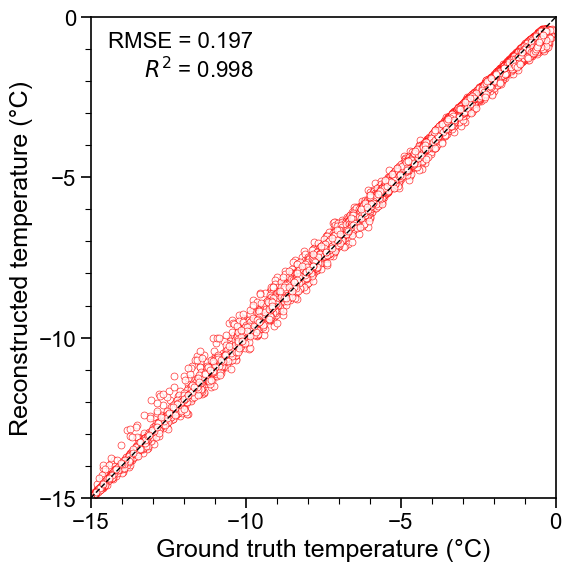

In [13]:
stride = 15  
y_true_p = y_true[::stride]
y_pred_p = y_pred[::stride]

import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 16
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["xtick.labelsize"] = 16
mpl.rcParams["ytick.labelsize"] = 16
mpl.rcParams["legend.fontsize"] = 14

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    y_true_p, y_pred_p,
    s=25,
    facecolors="white",     
    edgecolors="red",       
    linewidths=0.5,
    alpha=0.8,
    rasterized=True         
)

ax.plot(
    [-15, 0], [-15, 0],
    linestyle="--",
    color="black",
    linewidth=1.0
)

ax.set_xlim(-15, 0)
ax.set_ylim(-15, 0)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(1))

ax.tick_params(which="major", length=7, width=1.2)
ax.tick_params(which="minor", length=4, width=0.8)

ax.set_xlabel("Ground truth temperature (°C)")
ax.set_ylabel("Reconstructed temperature (°C)")

ax.text(
    0.35, 0.03 + 0.94,
    f"RMSE = {rmse:.3f}\n$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=16
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.grid(False)
plt.tight_layout()
plt.show()